In [1]:
import numpy as np
import pandas as pd

## Импорт данных, отбор нужных рядов

In [2]:
from data_utils import prepare_filtered_sample, plot_series_acf

res = prepare_filtered_sample(
    data_dir="data",
    lag=12,
    alpha=0.05,
    min_len=48,
    n_series=200,
    seed=42,
    save=True,
)

df_selected = res["df_selected"]
selected_ids = res["selected_ids"]

91.7MiB [00:03, 27.4MiB/s]                           
INFO:datasetsforecast.utils:Successfully downloaded Monthly-train.csv, 91655432, bytes.
7.94MiB [00:00, 10.1MiB/s]                           
INFO:datasetsforecast.utils:Successfully downloaded Monthly-test.csv, 7942698, bytes.
4.34MiB [00:00, 53.8MiB/s]                 
INFO:datasetsforecast.utils:Successfully downloaded M4-info.csv, 4335598, bytes.
100%|██████████| 3.56M/3.56M [00:00<00:00, 8.10MiB/s]
INFO:datasetsforecast.utils:Successfully downloaded submission-Naive2.zip, 3564691, bytes.
INFO:datasetsforecast.utils:Decompressing zip file...
INFO:datasetsforecast.utils:Successfully decompressed data/m4/datasets/submission-Naive2.zip


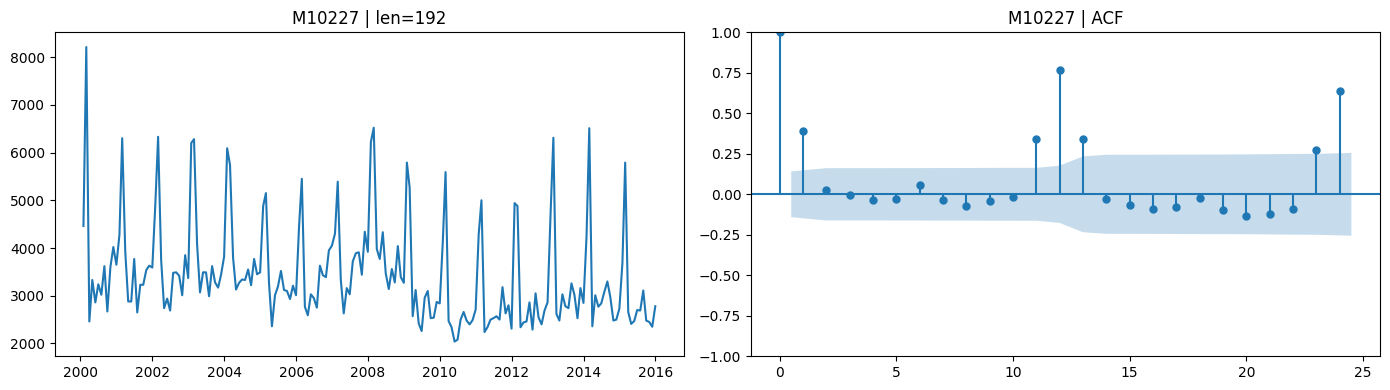

In [3]:
plot_series_acf(df_selected, uid=selected_ids[0], lags=24)

In [4]:
assert len(selected_ids) == 200
assert df_selected["unique_id"].nunique() == 200

## реализация сплита данных

In [5]:
from split_utils import check_series_length, make_splits_for_all_series, sanity_check_splits, inspect_one_series_split

length_check = check_series_length(df_selected, h=12, L=36)
display(length_check.head())
display(length_check.describe())

,unique_id,length,enough_for_holdout,enough_for_ml_tail
0,M10227,192,True,True
1,M10393,299,True,True
2,M10897,324,True,True
3,M1095,324,True,True
4,M1106,324,True,True


,length
count,200.000000
mean,304.680000
std,123.780961
min,97.000000
25%,220.000000
50%,317.500000
75%,324.000000
max,1092.000000


In [6]:
splits = make_splits_for_all_series(df_selected, h=12, L=36)

train_df = splits["train_df"]
holdout_df = splits["holdout_df"]
holdout_fit_df = splits["holdout_fit_df"]
holdout_pred_df = splits["holdout_pred_df"]
truth_df = splits["truth_df"]

sanity_check_splits(splits, df_selected, h=12, L=36)

splits look ok


In [7]:
parts = inspect_one_series_split(df_selected, uid=selected_ids[0], h=12, L=36)
display(parts["train_block"].tail())
display(parts["holdout_block"])
display(parts["holdout_fit"].tail(15))
display(parts["holdout_pred"].tail(15))
display(parts["truth"])

uid: M10227
full len: 192
train len: 180
holdout len: 12
holdout_fit len: 48
holdout_pred len: 48
truth len: 12


,unique_id,ds,y
175,M10227,2014-08-31,3300.0
176,M10227,2014-09-30,2970.0
177,M10227,2014-10-31,2480.0
178,M10227,2014-11-30,2500.0
179,M10227,2014-12-31,2730.0


,unique_id,ds,y
180,M10227,2015-01-31,3690.0
181,M10227,2015-02-28,5790.0
182,M10227,2015-03-31,2660.0
183,M10227,2015-04-30,2410.0
184,M10227,2015-05-31,2470.0
185,M10227,2015-06-30,2700.0
186,M10227,2015-07-31,2690.0
187,M10227,2015-08-31,3110.0
188,M10227,2015-09-30,2480.0
189,M10227,2015-10-31,2450.0


,unique_id,ds,y
177,M10227,2014-10-31,2480.0
178,M10227,2014-11-30,2500.0
179,M10227,2014-12-31,2730.0
180,M10227,2015-01-31,3690.0
181,M10227,2015-02-28,5790.0
182,M10227,2015-03-31,2660.0
183,M10227,2015-04-30,2410.0
184,M10227,2015-05-31,2470.0
185,M10227,2015-06-30,2700.0
186,M10227,2015-07-31,2690.0


,unique_id,ds,y
177,M10227,2014-10-31,2480.0
178,M10227,2014-11-30,2500.0
179,M10227,2014-12-31,2730.0
180,M10227,2015-01-31,NaN
181,M10227,2015-02-28,NaN
182,M10227,2015-03-31,NaN
183,M10227,2015-04-30,NaN
184,M10227,2015-05-31,NaN
185,M10227,2015-06-30,NaN
186,M10227,2015-07-31,NaN


,unique_id,ds,y
180,M10227,2015-01-31,3690.0
181,M10227,2015-02-28,5790.0
182,M10227,2015-03-31,2660.0
183,M10227,2015-04-30,2410.0
184,M10227,2015-05-31,2470.0
185,M10227,2015-06-30,2700.0
186,M10227,2015-07-31,2690.0
187,M10227,2015-08-31,3110.0
188,M10227,2015-09-30,2480.0
189,M10227,2015-10-31,2450.0


## Реализация функций метрик

In [8]:
from metrics_utils import (
    smape,
    mase,
    evaluate_one_model_per_series,
    summarize_metrics,
    compare_models,
    count_series_wins,
    compare_two_models_per_series,
)

In [9]:
y_true = np.array([10, 20, 30, 40], dtype=float)
y_pred = np.array([12, 18, 33, 39], dtype=float)
y_train = np.array([8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34], dtype=float)

print(smape(y_true, y_pred))
print(mase(y_train, y_true, y_pred, m=1))

10.19089726618041
1.0


## Реализация бейслайнов

In [10]:
from baseline_utils import run_all_baselines, sanity_check_baseline_forecasts

baseline_res = run_all_baselines(
    train_df=train_df,
    h=12,
    season_length=12,
    freq="M",
)

forecasts_df = baseline_res["forecasts_df"]
baseline_pred_dict = baseline_res["pred_dict"]

sanity_check_baseline_forecasts(
    forecasts_df=forecasts_df,
    h=12,
    n_ids_expected=train_df["unique_id"].nunique(),
)

display(forecasts_df.head())
print(forecasts_df.columns.tolist())

baseline forecasts look ok


,unique_id,ds,Naive,SeasonalNaive,AutoETS,AutoTheta
0,M10227,2015-01-31,2730.0,4240.0,4547.166544,4310.382884
1,M10227,2015-02-28,2730.0,6510.0,5600.441798,5027.897835
2,M10227,2015-03-31,2730.0,2360.0,2695.835076,2664.423026
3,M10227,2015-04-30,2730.0,3010.0,2466.646335,2403.449896
4,M10227,2015-05-31,2730.0,2770.0,2580.800539,2540.647052


['unique_id', 'ds', 'Naive', 'SeasonalNaive', 'AutoETS', 'AutoTheta']


In [11]:
from metrics_utils import evaluate_one_model_per_series, compare_models, count_series_wins

baseline_metrics = {}

for model_name, pred_df in baseline_pred_dict.items():
    baseline_metrics[model_name] = evaluate_one_model_per_series(
        train_df=train_df,
        truth_df=truth_df,
        pred_df=pred_df,
        m=12,
    )

baseline_summary = compare_models(baseline_metrics)
baseline_wins_mase = count_series_wins(baseline_metrics, metric="mase")
baseline_wins_smape = count_series_wins(baseline_metrics, metric="smape")

display(baseline_summary)
display(baseline_wins_mase)
display(baseline_wins_smape)

,model,mean_smape,median_smape,mean_mase,median_mase,n_series
0,AutoETS,6.458918,3.122006,0.754907,0.621262,200
1,AutoTheta,6.323814,2.936599,0.762348,0.616357,200
2,SeasonalNaive,7.643086,3.975576,0.999942,0.819032,200
3,Naive,8.499195,3.805800,1.155148,0.792667,200


,model,n_wins,share_wins
0,AutoTheta,64,0.320
1,AutoETS,61,0.305
2,Naive,46,0.230
3,SeasonalNaive,29,0.145


,model,n_wins,share_wins
0,AutoTheta,64,0.320
1,AutoETS,59,0.295
2,Naive,45,0.225
3,SeasonalNaive,32,0.160


## фиксация того какие спецификации создаем

In [15]:
from feature_configs import get_all_feature_configs, get_feature_config_names, get_feature_config_by_name

configs = get_all_feature_configs()
print(get_feature_config_names())
for cfg in configs:
    print(cfg)

print(get_feature_config_by_name("lags_seasonal"))

['lags_only', 'lags_seasonal', 'lags_calendar', 'lags_fourier', 'lags_seasonal_calendar', 'lags_seasonal_fourier']
{'name': 'lags_only', 'use_lags': True, 'lags': [1, 2, 3, 6, 12], 'use_seasonal_lags': False, 'seasonal_lags': [], 'use_calendar': False, 'calendar_features': [], 'use_fourier': False, 'fourier_period': 12, 'fourier_order': 0}
{'name': 'lags_seasonal', 'use_lags': True, 'lags': [1, 2, 3, 6, 12], 'use_seasonal_lags': True, 'seasonal_lags': [12, 24], 'use_calendar': False, 'calendar_features': [], 'use_fourier': False, 'fourier_period': 12, 'fourier_order': 0}
{'name': 'lags_calendar', 'use_lags': True, 'lags': [1, 2, 3, 6, 12], 'use_seasonal_lags': False, 'seasonal_lags': [], 'use_calendar': True, 'calendar_features': ['month', 'quarter'], 'use_fourier': False, 'fourier_period': 12, 'fourier_order': 0}
{'name': 'lags_fourier', 'use_lags': True, 'lags': [1, 2, 3, 6, 12], 'use_seasonal_lags': False, 'seasonal_lags': [], 'use_calendar': False, 'calendar_features': [], 'use_fou

## запуск генерации признаков из конфига

In [16]:
from feature_configs import get_all_feature_configs, get_feature_config_by_name
from feature_utils import prepare_feature_frame, get_feature_columns, get_categorical_columns, drop_na_feature_rows

cfg = get_feature_config_by_name("lags_seasonal_calendar")
print(cfg)

tmp = prepare_feature_frame(df_selected, cfg)
print(tmp.columns.tolist())
display(tmp.head(15))

print(get_feature_columns(cfg))
print(get_categorical_columns(cfg))

tmp2 = drop_na_feature_rows(tmp, cfg)
display(tmp2.head())
print(tmp.shape, tmp2.shape)

{'name': 'lags_seasonal_calendar', 'use_lags': True, 'lags': [1, 2, 3, 6, 12], 'use_seasonal_lags': True, 'seasonal_lags': [12, 24], 'use_calendar': True, 'calendar_features': ['month', 'quarter'], 'use_fourier': False, 'fourier_period': 12, 'fourier_order': 0}
['unique_id', 'ds', 'y', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'slag_12', 'slag_24', 'month', 'quarter']


,unique_id,ds,y,lag_1,lag_2,lag_3,lag_6,lag_12,slag_12,slag_24,month,quarter
0,M10227,2000-01-31,4460.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,M10227,2000-02-29,8210.0,4460.0,NaN,NaN,NaN,NaN,NaN,NaN,2,1
2,M10227,2000-03-31,2460.0,8210.0,4460.0,NaN,NaN,NaN,NaN,NaN,3,1
3,M10227,2000-04-30,3330.0,2460.0,8210.0,4460.0,NaN,NaN,NaN,NaN,4,2
4,M10227,2000-05-31,2860.0,3330.0,2460.0,8210.0,NaN,NaN,NaN,NaN,5,2
5,M10227,2000-06-30,3240.0,2860.0,3330.0,2460.0,NaN,NaN,NaN,NaN,6,2
6,M10227,2000-07-31,3020.0,3240.0,2860.0,3330.0,4460.0,NaN,NaN,NaN,7,3
7,M10227,2000-08-31,3620.0,3020.0,3240.0,2860.0,8210.0,NaN,NaN,NaN,8,3
8,M10227,2000-09-30,2670.0,3620.0,3020.0,3240.0,2460.0,NaN,NaN,NaN,9,3
9,M10227,2000-10-31,3600.0,2670.0,3620.0,3020.0,3330.0,NaN,NaN,NaN,10,4


['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'slag_12', 'slag_24', 'month', 'quarter']
['month', 'quarter']


,unique_id,ds,y,lag_1,lag_2,lag_3,lag_6,lag_12,slag_12,slag_24,month,quarter
0,M10227,2002-01-31,4930.0,3590.0,3630.0,3540.0,2650.0,4280.0,4280.0,4460.0,1,1
1,M10227,2002-02-28,6330.0,4930.0,3590.0,3630.0,3230.0,6300.0,6300.0,8210.0,2,1
2,M10227,2002-03-31,3750.0,6330.0,4930.0,3590.0,3230.0,3930.0,3930.0,2460.0,3,1
3,M10227,2002-04-30,2740.0,3750.0,6330.0,4930.0,3540.0,2880.0,2880.0,3330.0,4,2
4,M10227,2002-05-31,2940.0,2740.0,3750.0,6330.0,3630.0,2880.0,2880.0,2860.0,5,2


(60936, 12) (56136, 12)


In [17]:
for name in ["lags_only", "lags_seasonal", "lags_calendar", "lags_fourier"]:
    cfg = get_feature_config_by_name(name)
    tmp = prepare_feature_frame(df_selected, cfg)
    tmp = drop_na_feature_rows(tmp, cfg)
    print(name, tmp.shape, get_feature_columns(cfg))

lags_only (58536, 8) ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12']
lags_seasonal (56136, 10) ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'slag_12', 'slag_24']
lags_calendar (58536, 10) ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'month', 'quarter']
lags_fourier (58536, 12) ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2']


## тест генерации нужных окон для catboost-mimo

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import window_utils

importlib.reload(window_utils)

<module 'window_utils' from '/Users/mark/Downloads/TS_HW3_makhmudov/window_utils.py'>

In [28]:
from feature_configs import get_feature_config_by_name
from window_utils import make_holdout_windows_all_series, sanity_check_window_outputs

cfg = get_feature_config_by_name("lags_seasonal_calendar")

for offset in [0, 4, 8]:
    X_h, Y_h = make_holdout_windows_all_series(
        holdout_df=holdout_fit_df,
        config=cfg,
        history=36,
        model_horizon=4,
        block_offset=offset,
    )
    print("offset =", offset)
    sanity_check_window_outputs(X_h, Y_h, model_horizon=4)
    display(X_h.head(2))
    print(Y_h[:2])

offset = 0
window outputs look ok
X shape: (200, 16)
Y shape: (200, 4)


,lag_1,lag_2,lag_3,lag_6,slag_12,slag_24,month_t1,quarter_t1,month_t2,quarter_t2,month_t3,quarter_t3,month_t4,quarter_t4,unique_id,block_offset
0,2730.0,2500.0,2480.0,3080.0,4240.0,4740.0,1,1,2,1,3,1,4,2,M10227,0
1,1797.0,1902.7,1921.6,1886.6,1971.4,1997.0,12,4,1,1,2,1,3,1,M10393,0


[[3690.  5790.  2660.  2410. ]
 [1798.2 1505.7 1727.4 1866.7]]
offset = 4
window outputs look ok
X shape: (200, 16)
Y shape: (200, 4)


,lag_1,lag_2,lag_3,lag_6,slag_12,slag_24,month_t1,quarter_t1,month_t2,quarter_t2,month_t3,quarter_t3,month_t4,quarter_t4,unique_id,block_offset
0,2730.0,2500.0,2480.0,3080.0,4240.0,4740.0,5,2,6,2,7,3,8,3,M10227,4
1,1797.0,1902.7,1921.6,1886.6,1971.4,1997.0,4,2,5,2,6,2,7,3,M10393,4


[[2470.  2700.  2690.  3110. ]
 [1773.7 1827.7 1955.  1756. ]]
offset = 8
window outputs look ok
X shape: (200, 16)
Y shape: (200, 4)


,lag_1,lag_2,lag_3,lag_6,slag_12,slag_24,month_t1,quarter_t1,month_t2,quarter_t2,month_t3,quarter_t3,month_t4,quarter_t4,unique_id,block_offset
0,2730.0,2500.0,2480.0,3080.0,4240.0,4740.0,9,3,10,4,11,4,12,4,M10227,8
1,1797.0,1902.7,1921.6,1886.6,1971.4,1997.0,8,3,9,3,10,4,11,4,M10393,8


[[2480.  2450.  2350.  2780. ]
 [2032.2 1922.9 1890.5 1975.9]]


## реализация catboost direct mimo с учетом горизонта

In [ ]:
from feature_configs import get_feature_config_by_name
from model_utils import run_catboost_pipeline, sanity_check_pred_df

cfg = get_feature_config_by_name("lags_seasonal_calendar")

catboost_params = {
    "loss_function": "RMSE",
    "iterations": 200,
    "depth": 6,
    "learning_rate": 0.05,
    "verbose": False,
    "random_seed": 42,
}

ml_res = run_catboost_pipeline(
    train_df=train_df,
    holdout_df=holdout_fit_df,
    config=cfg,
    history=36,
    h=12,
    model_horizon=4,
    catboost_params=catboost_params,
)

pred_df_ml = ml_res["pred_df"]
display(pred_df_ml.head())

sanity_check_pred_df(
    pred_df=pred_df_ml,
    h=12,
    n_ids_expected=train_df["unique_id"].nunique(),
)

## тест визуальных штук

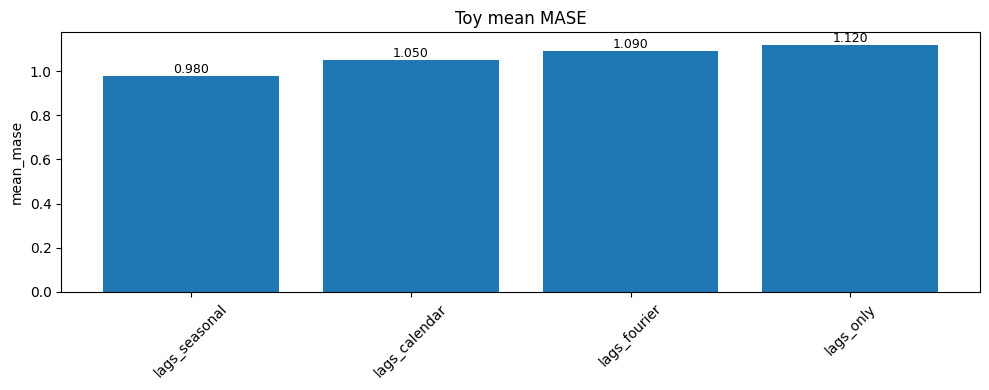

In [30]:
from viz_utils import plot_metric_bar
import pandas as pd

toy_df = pd.DataFrame({
    "model": ["lags_only", "lags_seasonal", "lags_calendar", "lags_fourier"],
    "mean_mase": [1.12, 0.98, 1.05, 1.09],
})

plot_metric_bar(
    df=toy_df,
    x_col="model",
    y_col="mean_mase",
    title="Toy mean MASE",
    ascending=True,
)

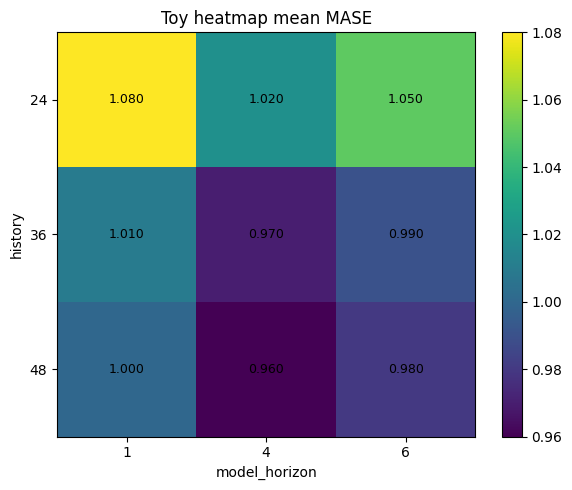

In [31]:
from viz_utils import plot_metric_heatmap
import pandas as pd

toy_grid = pd.DataFrame({
    "history": [24, 24, 24, 36, 36, 36, 48, 48, 48],
    "model_horizon": [1, 4, 6, 1, 4, 6, 1, 4, 6],
    "mean_mase": [1.08, 1.02, 1.05, 1.01, 0.97, 0.99, 1.00, 0.96, 0.98],
})

plot_metric_heatmap(
    df=toy_grid,
    value_col="mean_mase",
    index_col="history",
    columns_col="model_horizon",
    title="Toy heatmap mean MASE",
)